<a href="https://colab.research.google.com/github/gaga0321/scRNA-aging-analysis/blob/main/scRNA_aging_analysis_Trachea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 72.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.

/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


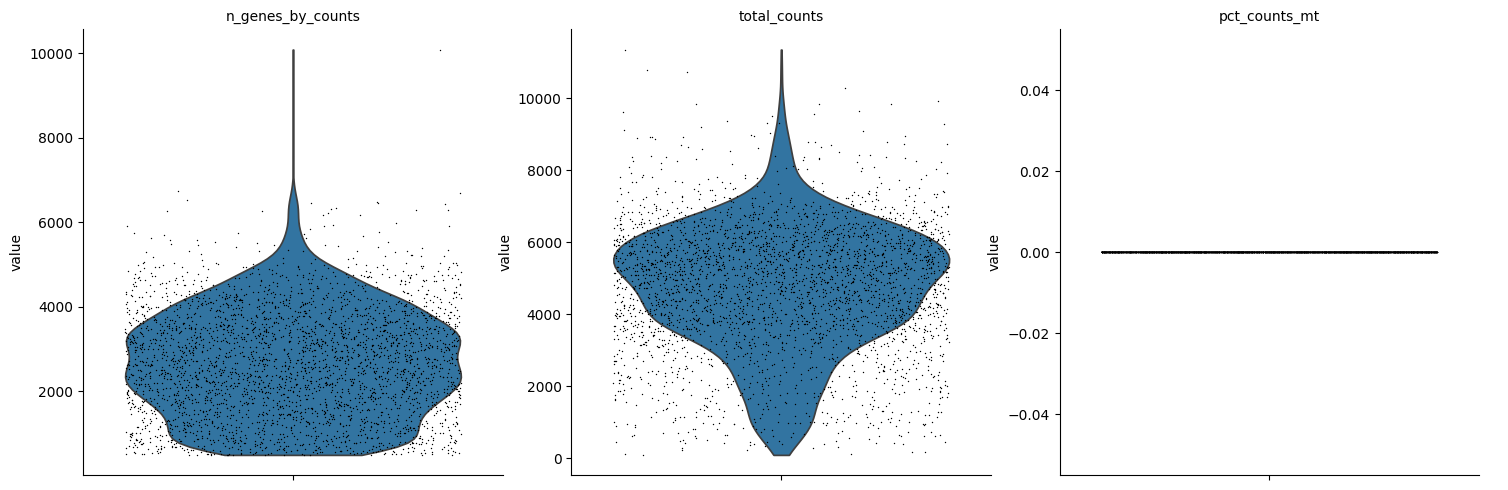

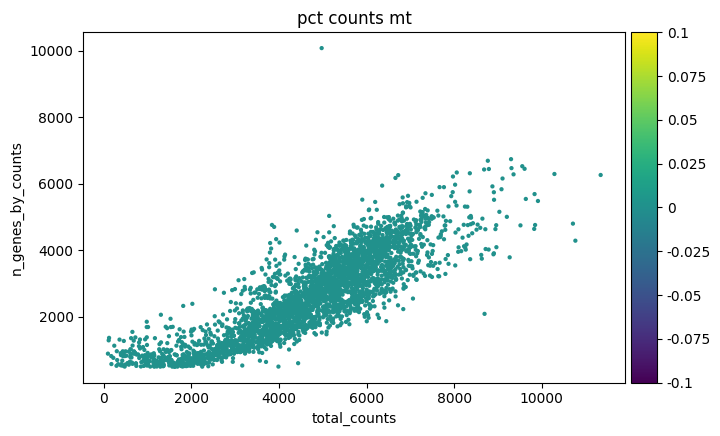

['FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']


In [1]:
!pip install scanpy
import scanpy as sc
adata_aging = sc.read_h5ad("tabula-muris-senis-facs-processed-official-annotations-Trachea.h5ad")
adata_aging.var['mt'] = adata_aging.var_names.str.lower().str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata_aging, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
sc.pl.violin(
    adata_aging,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True,
    size=1
)
sc.pl.scatter(adata_aging, x='total_counts', y='n_genes_by_counts', color='pct_counts_mt')
print(list(adata_aging.obs.columns))

In [2]:
import scanpy as sc
adata_aging.var['mt'] = adata_aging.var_names.str.lower().str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata_aging, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
print(f"Cells before QC: {adata_aging.n_obs}")
adata_aging = adata_aging[
    (adata_aging.obs.n_genes_by_counts < 6000) &
    (adata_aging.obs.n_genes_by_counts > 500),
    :
].copy()
print(f"Cells after QC: {adata_aging.n_obs}")

Cells before QC: 3160
Cells after QC: 3143


Ages in this cohort: ['18m', '24m', '3m']

Top 5 cell types found in this tissue:
cell_ontology_class
fibroblast                                        1231
macrophage                                         430
basal epithelial cell of tracheobronchial tree     397
T cell                                             281
chondrocyte                                        275
Name: count, dtype: int64


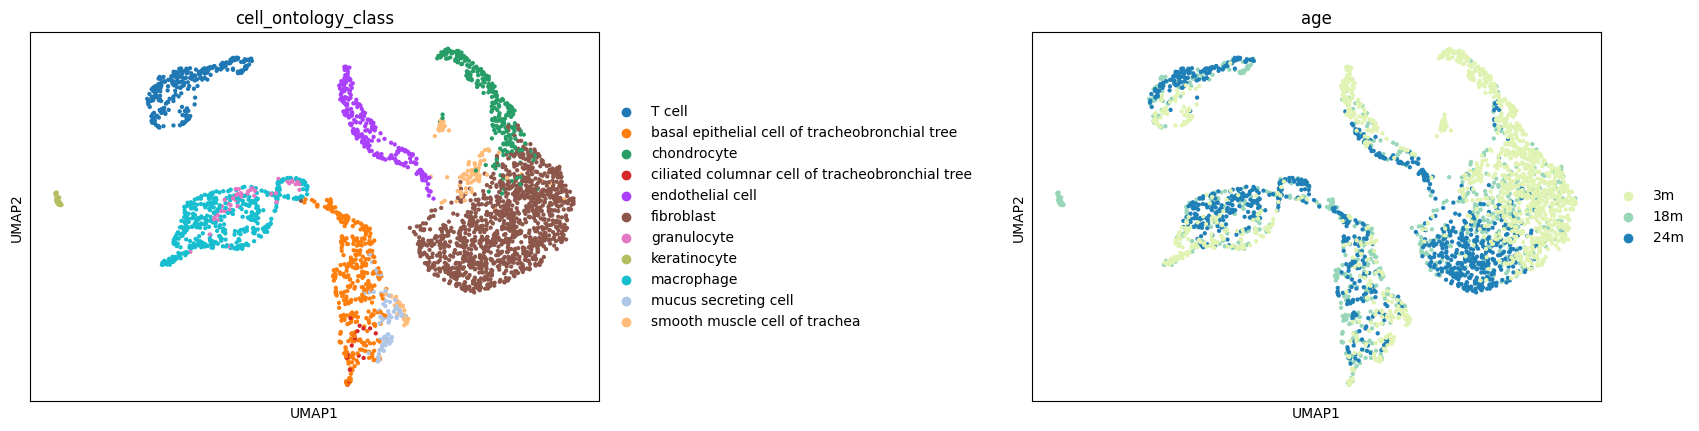

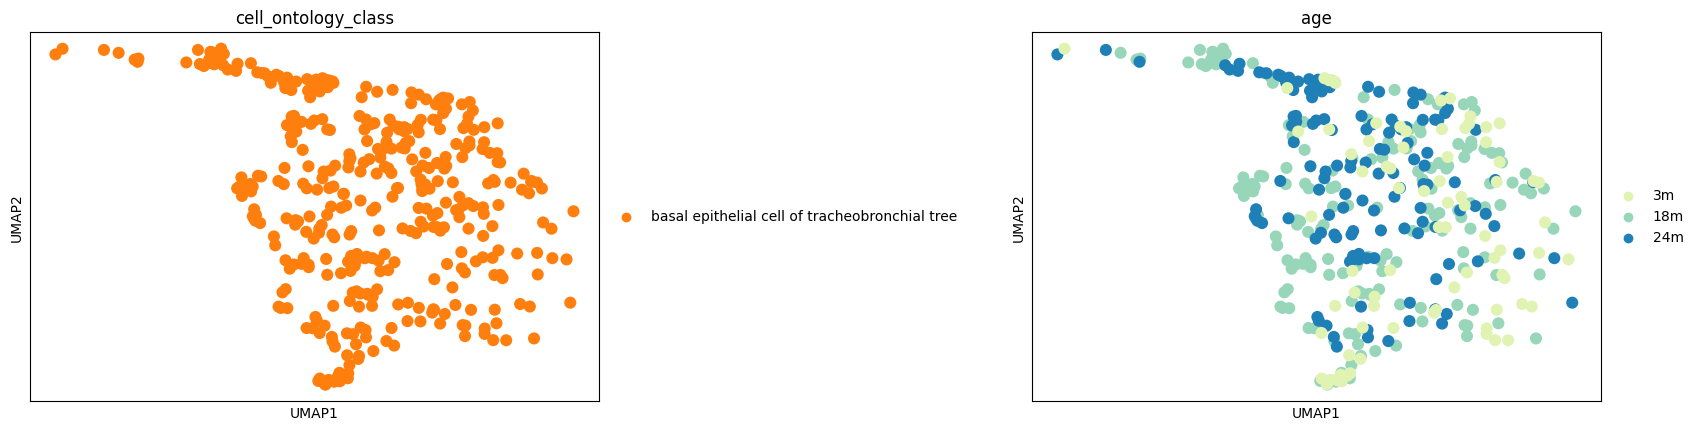

In [4]:
print("Ages in this cohort:", adata_aging.obs['age'].unique().tolist())
print("\nTop 5 cell types found in this tissue:")
print(adata_aging.obs['cell_ontology_class'].value_counts().head(5))
sc.pl.umap(adata_aging, color=['cell_ontology_class', 'age'], wspace=0.6)
basal_epithelial_cells = adata_aging[adata_aging.obs['cell_ontology_class'] == 'basal epithelial cell of tracheobronchial tree'].copy()
sc.pl.umap(basal_epithelial_cells, color=['cell_ontology_class', 'age'], wspace=0.6)

Top Upregulated mesenchymal stem cell of adipose Drivers (Ranked by Fold Change):
  18m_n     18m_l     18m_p
0  Pfn1  1.593793  0.001155
1  Cfl1  1.562770  0.043947


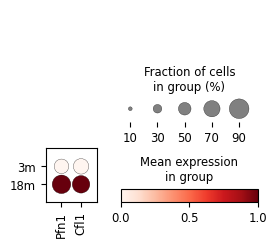

Top Downregulated mesenchymal stem cell of adipose Targets (Ranked by Fold Change):
     18m_n     18m_l         18m_p
0     Ins2 -7.910664  1.155202e-03
1     Ins1 -6.956377  1.028246e-02
2    Lars2 -2.714722  2.439408e-13
3   Celsr1 -2.350528  1.155202e-03
4       F3 -2.037516  7.396470e-03
5    Ahnak -1.750419  1.155202e-03
6     Tpm1 -1.702564  1.988363e-02
7     Fosb -1.429091  3.180642e-02
8      Gsn -1.313462  3.314841e-04
9    Sparc -0.537856  5.175188e-03
10     Dcn -0.422637  1.772430e-03


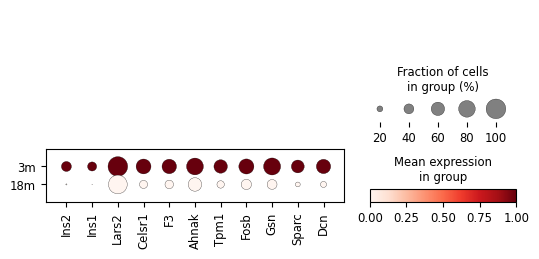

In [6]:
import pandas as pd
sc.tl.rank_genes_groups(
    basal_epithelial_cells,
    groupby='age',
    groups=['18m'],
    reference='3m',
    method='wilcoxon',
    use_raw=False
)
result = basal_epithelial_cells.uns['rank_genes_groups']
groups = result['names'].dtype.names
dataframe = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj']}
)

upregulated_genes = dataframe[
    (dataframe['18m_l'] > 0.25) &
    (dataframe['18m_l'] < 15) &
    (dataframe['18m_l'] != float('inf'))
]
final_up_df = upregulated_genes[upregulated_genes['18m_p'] < 0.05].sort_values(by='18m_l', ascending=False).reset_index(drop=True)
print("Top Upregulated mesenchymal stem cell of adipose Drivers (Ranked by Fold Change):")
print(final_up_df[['18m_n', '18m_l', '18m_p']].head(20))
top_genes = final_up_df['18m_n'].head(20).tolist()
subset = basal_epithelial_cells[basal_epithelial_cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset,
    var_names=top_genes,
    groupby='age',
    standard_scale='var',
    use_raw=False
)

downregulated_genes = dataframe[
    (dataframe['18m_l'] < -0.25) &
    (dataframe['18m_l'] > -15) &
    (dataframe['18m_l'] != float('-inf'))
]
final_down_df = downregulated_genes[downregulated_genes['18m_p'] < 0.05].sort_values(by='18m_l', ascending=True).reset_index(drop=True)
print("Top Downregulated mesenchymal stem cell of adipose Targets (Ranked by Fold Change):")
print(final_down_df[['18m_n', '18m_l', '18m_p']].head(20))
top_down_genes = final_down_df['18m_n'].head(20).tolist()
subset = basal_epithelial_cells[basal_epithelial_cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset,
    var_names=top_down_genes,
    groupby='age',
    standard_scale='var',
    use_raw=False
)

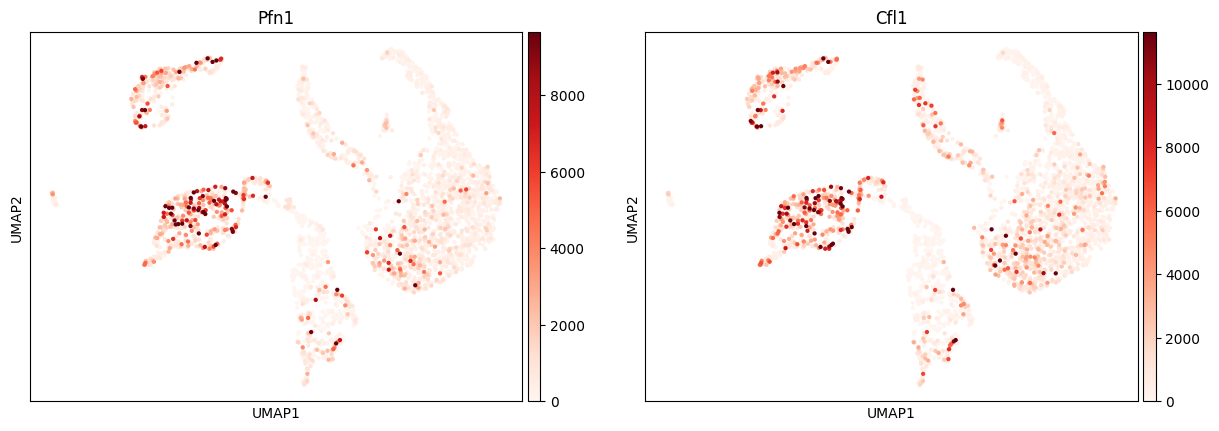

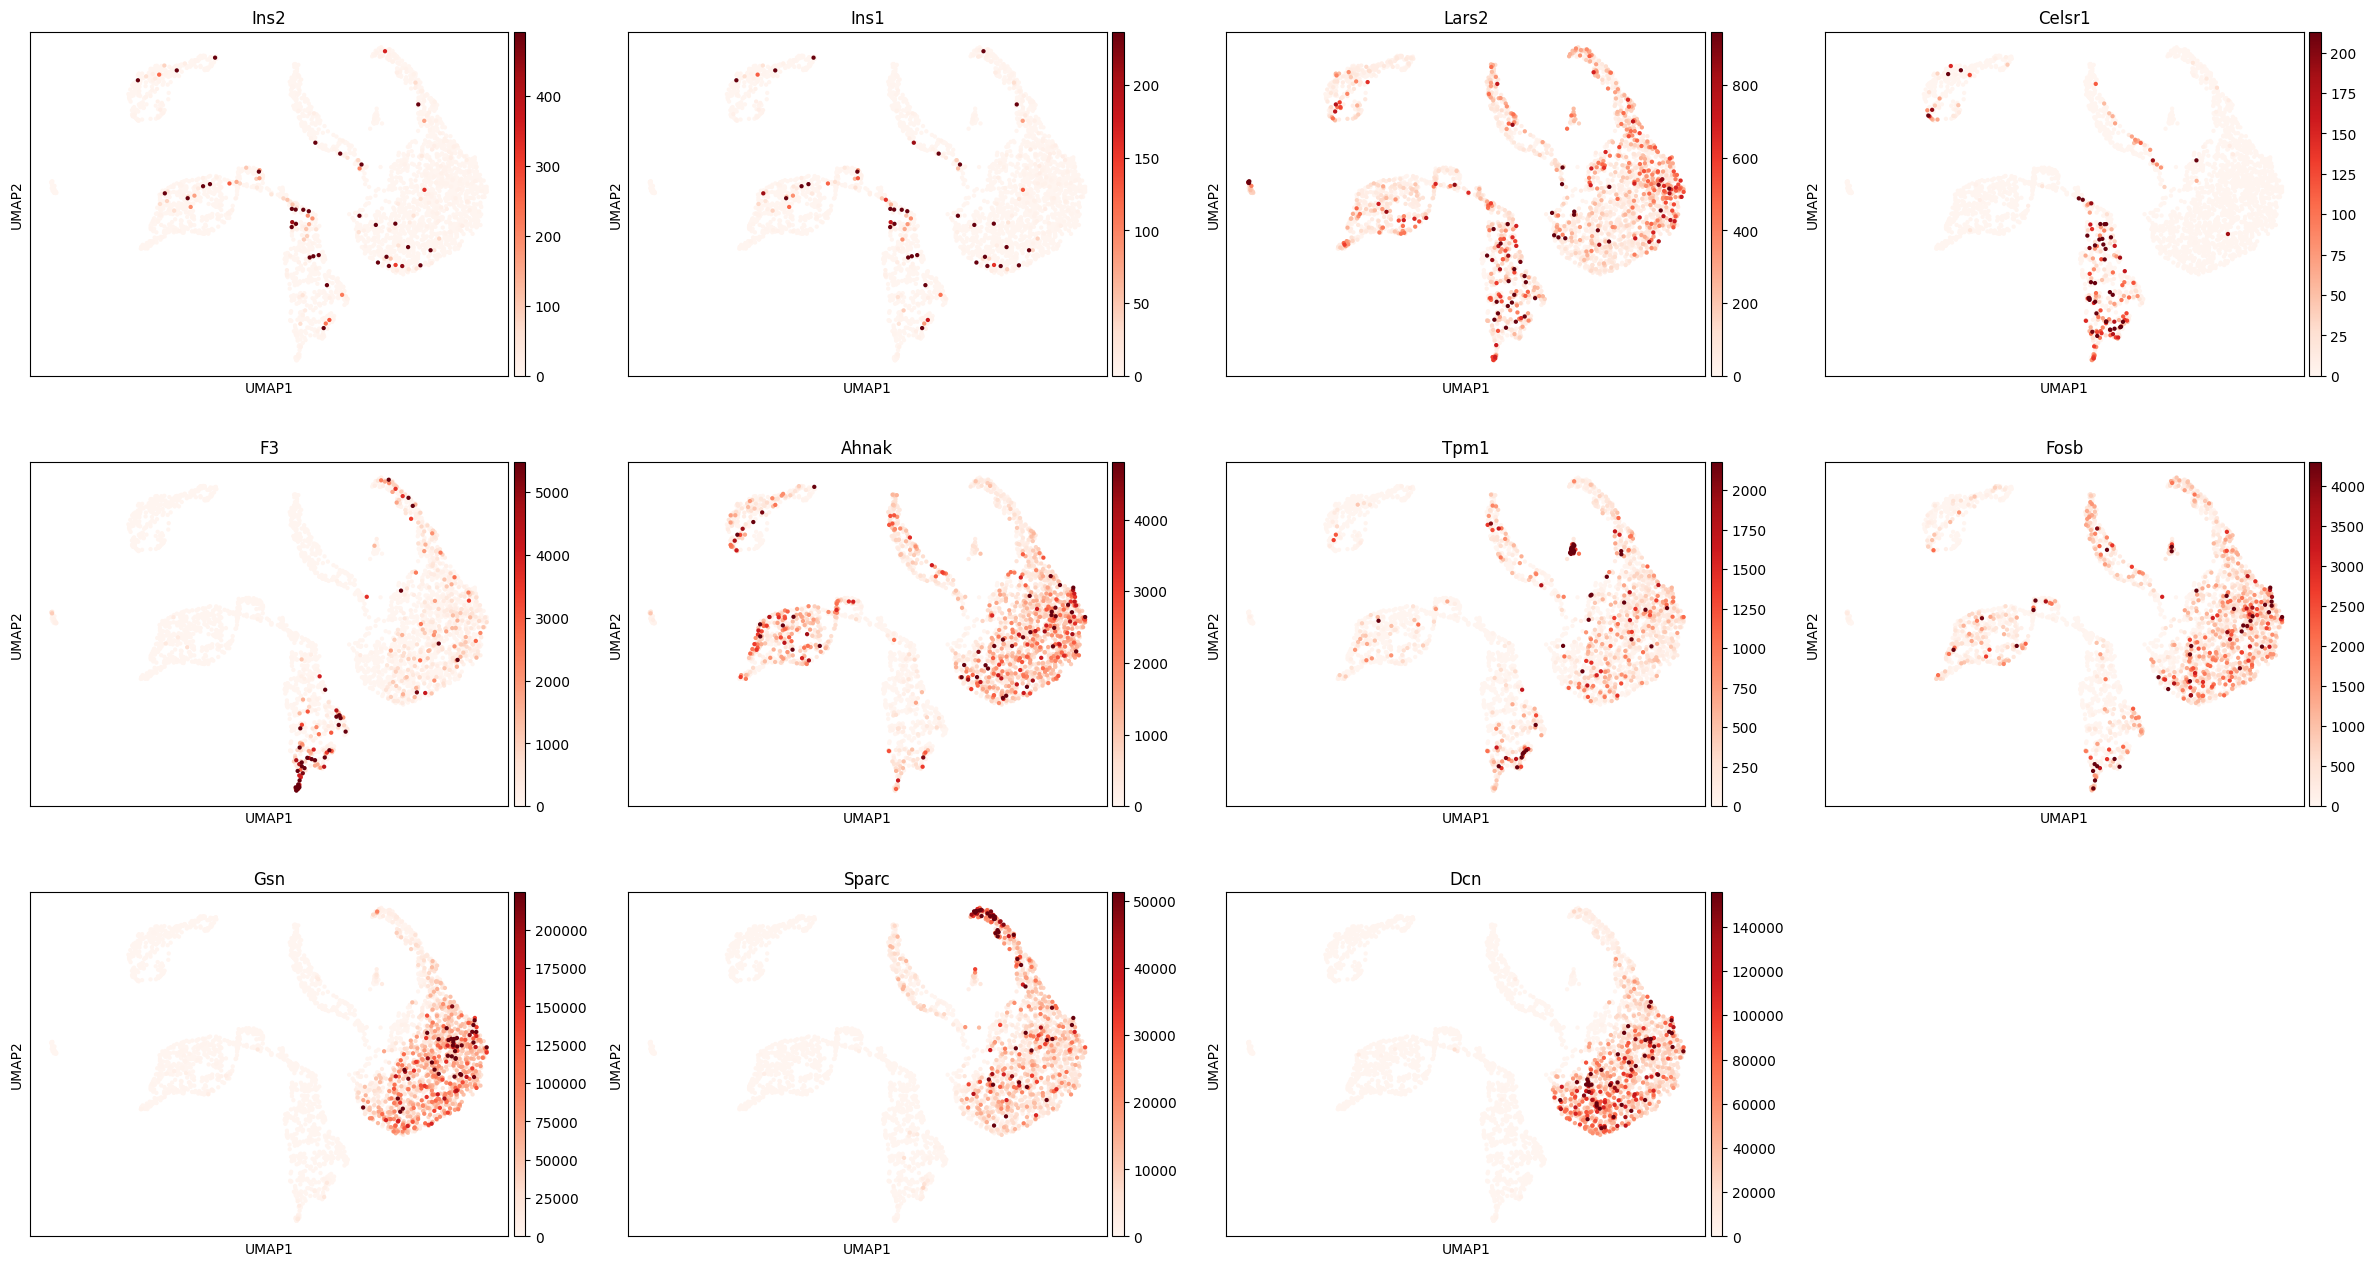

In [7]:
sc.pl.umap(
    adata_aging,
    color=top_genes,
    cmap='Reds',
    vmax='p99',
    ncols=4,
    title=top_genes
)
sc.pl.umap(
    adata_aging,
    color=top_down_genes,
    cmap='Reds',
    vmax='p99',
    ncols=4,
    title=top_down_genes
)

Top Upregulated mesenchymal stem cell of adipose Drivers (Ranked by Fold Change):
  18m_n     18m_l     18m_p
0  Pfn1  1.593793  0.001155
1  Cfl1  1.562770  0.043947


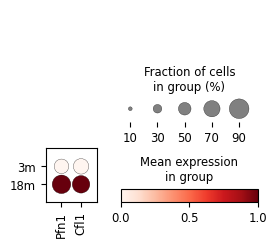

Top Downregulated mesenchymal stem cell of adipose Targets (Ranked by Fold Change):
    18m_n     18m_l         18m_p
0   Lars2 -2.714722  2.439408e-13
1  Celsr1 -2.350528  1.155202e-03
2      F3 -2.037516  7.396470e-03
3    Tpm1 -1.702564  1.988363e-02
4    Fosb -1.429091  3.180642e-02


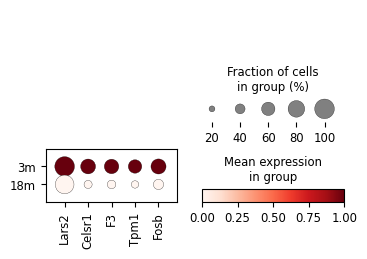

In [8]:
import pandas as pd
sc.tl.rank_genes_groups(
    basal_epithelial_cells,
    groupby='age',
    groups=['18m'],
    reference='3m',
    method='wilcoxon',
    use_raw=False
)
result = basal_epithelial_cells.uns['rank_genes_groups']
groups = result['names'].dtype.names
dataframe = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj']}
)

blacklist = ('Ins1', 'Ins2', 'Sparc', 'Dcn', 'Gsn', 'Ahnak')
dataframe = dataframe[~dataframe['18m_n'].str.startswith(blacklist)]

upregulated_genes = dataframe[
    (dataframe['18m_l'] > 0.25) &
    (dataframe['18m_l'] < 15) &
    (dataframe['18m_l'] != float('inf'))
]
final_up_df = upregulated_genes[upregulated_genes['18m_p'] < 0.05].sort_values(by='18m_l', ascending=False).reset_index(drop=True)
print("Top Upregulated mesenchymal stem cell of adipose Drivers (Ranked by Fold Change):")
print(final_up_df[['18m_n', '18m_l', '18m_p']].head(20))
top_genes = final_up_df['18m_n'].head(20).tolist()
subset = basal_epithelial_cells[basal_epithelial_cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset,
    var_names=top_genes,
    groupby='age',
    standard_scale='var',
    use_raw=False
)

downregulated_genes = dataframe[
    (dataframe['18m_l'] < -0.25) &
    (dataframe['18m_l'] > -15) &
    (dataframe['18m_l'] != float('-inf'))
]
final_down_df = downregulated_genes[downregulated_genes['18m_p'] < 0.05].sort_values(by='18m_l', ascending=True).reset_index(drop=True)
print("Top Downregulated mesenchymal stem cell of adipose Targets (Ranked by Fold Change):")
print(final_down_df[['18m_n', '18m_l', '18m_p']].head(20))
top_down_genes = final_down_df['18m_n'].head(20).tolist()
subset = basal_epithelial_cells[basal_epithelial_cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset,
    var_names=top_down_genes,
    groupby='age',
    standard_scale='var',
    use_raw=False
)

Top 10 Upregulated Pathways in Aged mesenchymal stem cell of adipose:
                                                Term  Adjusted P-value Overlap
0  Positive Regulation of Ruffle Assembly (GO:190...          0.007493    1/12
1  Negative Regulation of Actin Filament Polymeri...          0.007493    1/19
2  Negative Regulation of Stress Fiber Assembly (...          0.007493    1/24
3         Regulation of Ruffle Assembly (GO:1900027)          0.007493    1/24
4  Regulation of Actin Filament Bundle Assembly (...          0.007493    1/26
5  Regulation of Actin Polymerization or Depolyme...          0.007493    1/26
6  Negative Regulation of Actin Filament Bundle A...          0.007493    1/27
7  Negative Regulation of Protein Polymerization ...          0.007493    1/28
8  Negative Regulation of Cytoskeleton Organizati...          0.007493    1/29
9  Positive Regulation of ATP-dependent Activity ...          0.007493    1/31


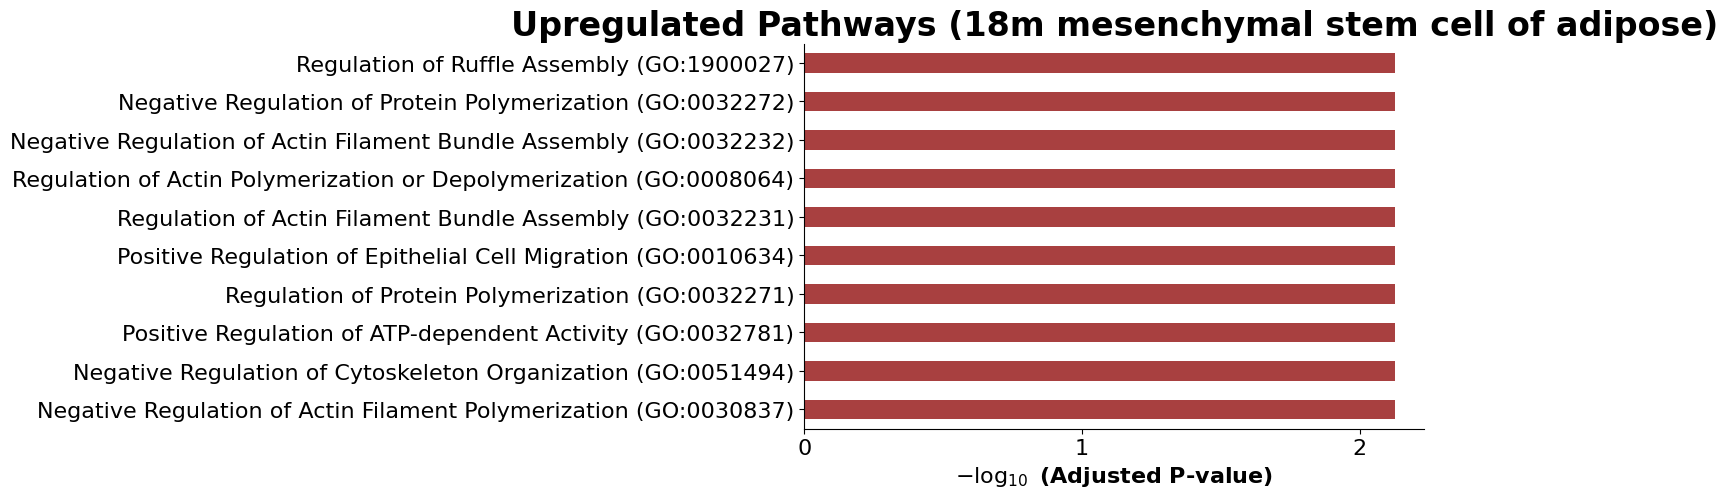

In [10]:
!pip install gseapy
import gseapy as gp
import matplotlib.pyplot as plt

upregulated_genes = dataframe[
    (dataframe['18m_l'] > 0.25) &
    (dataframe['18m_l'] < 15) &
    (dataframe['18m_l'] != float('inf'))
]
final_up_df = upregulated_genes[upregulated_genes['18m_p'] < 0.05].sort_values(by='18m_l', ascending=False).reset_index(drop=True)

clean_up_genes = final_up_df['18m_n'].head(300).tolist()
enr_up = gp.enrichr(
    gene_list=clean_up_genes,
    gene_sets='GO_Biological_Process_2025',
    organism='mouse',
    outdir=None
)
results_up_df = enr_up.results
print("Top 10 Upregulated Pathways in Aged mesenchymal stem cell of adipose:")
print(results_up_df[['Term', 'Adjusted P-value', 'Overlap']].head(10))
gp.barplot(
    enr_up.results,
    column="Adjusted P-value",
    title='Upregulated Pathways (18m mesenchymal stem cell of adipose)',
    top_term=10,
    figsize=(8, 5),
    color='darkred'
)
plt.show()